**Disciplina: ACA052 - Meteorologia Sinótica I**

Monitor: Ronald Guiuseppi Ramírez Nina

File: Aula_04.ipynb

#**Plotagem dos Códigos Metar na América do Sul**

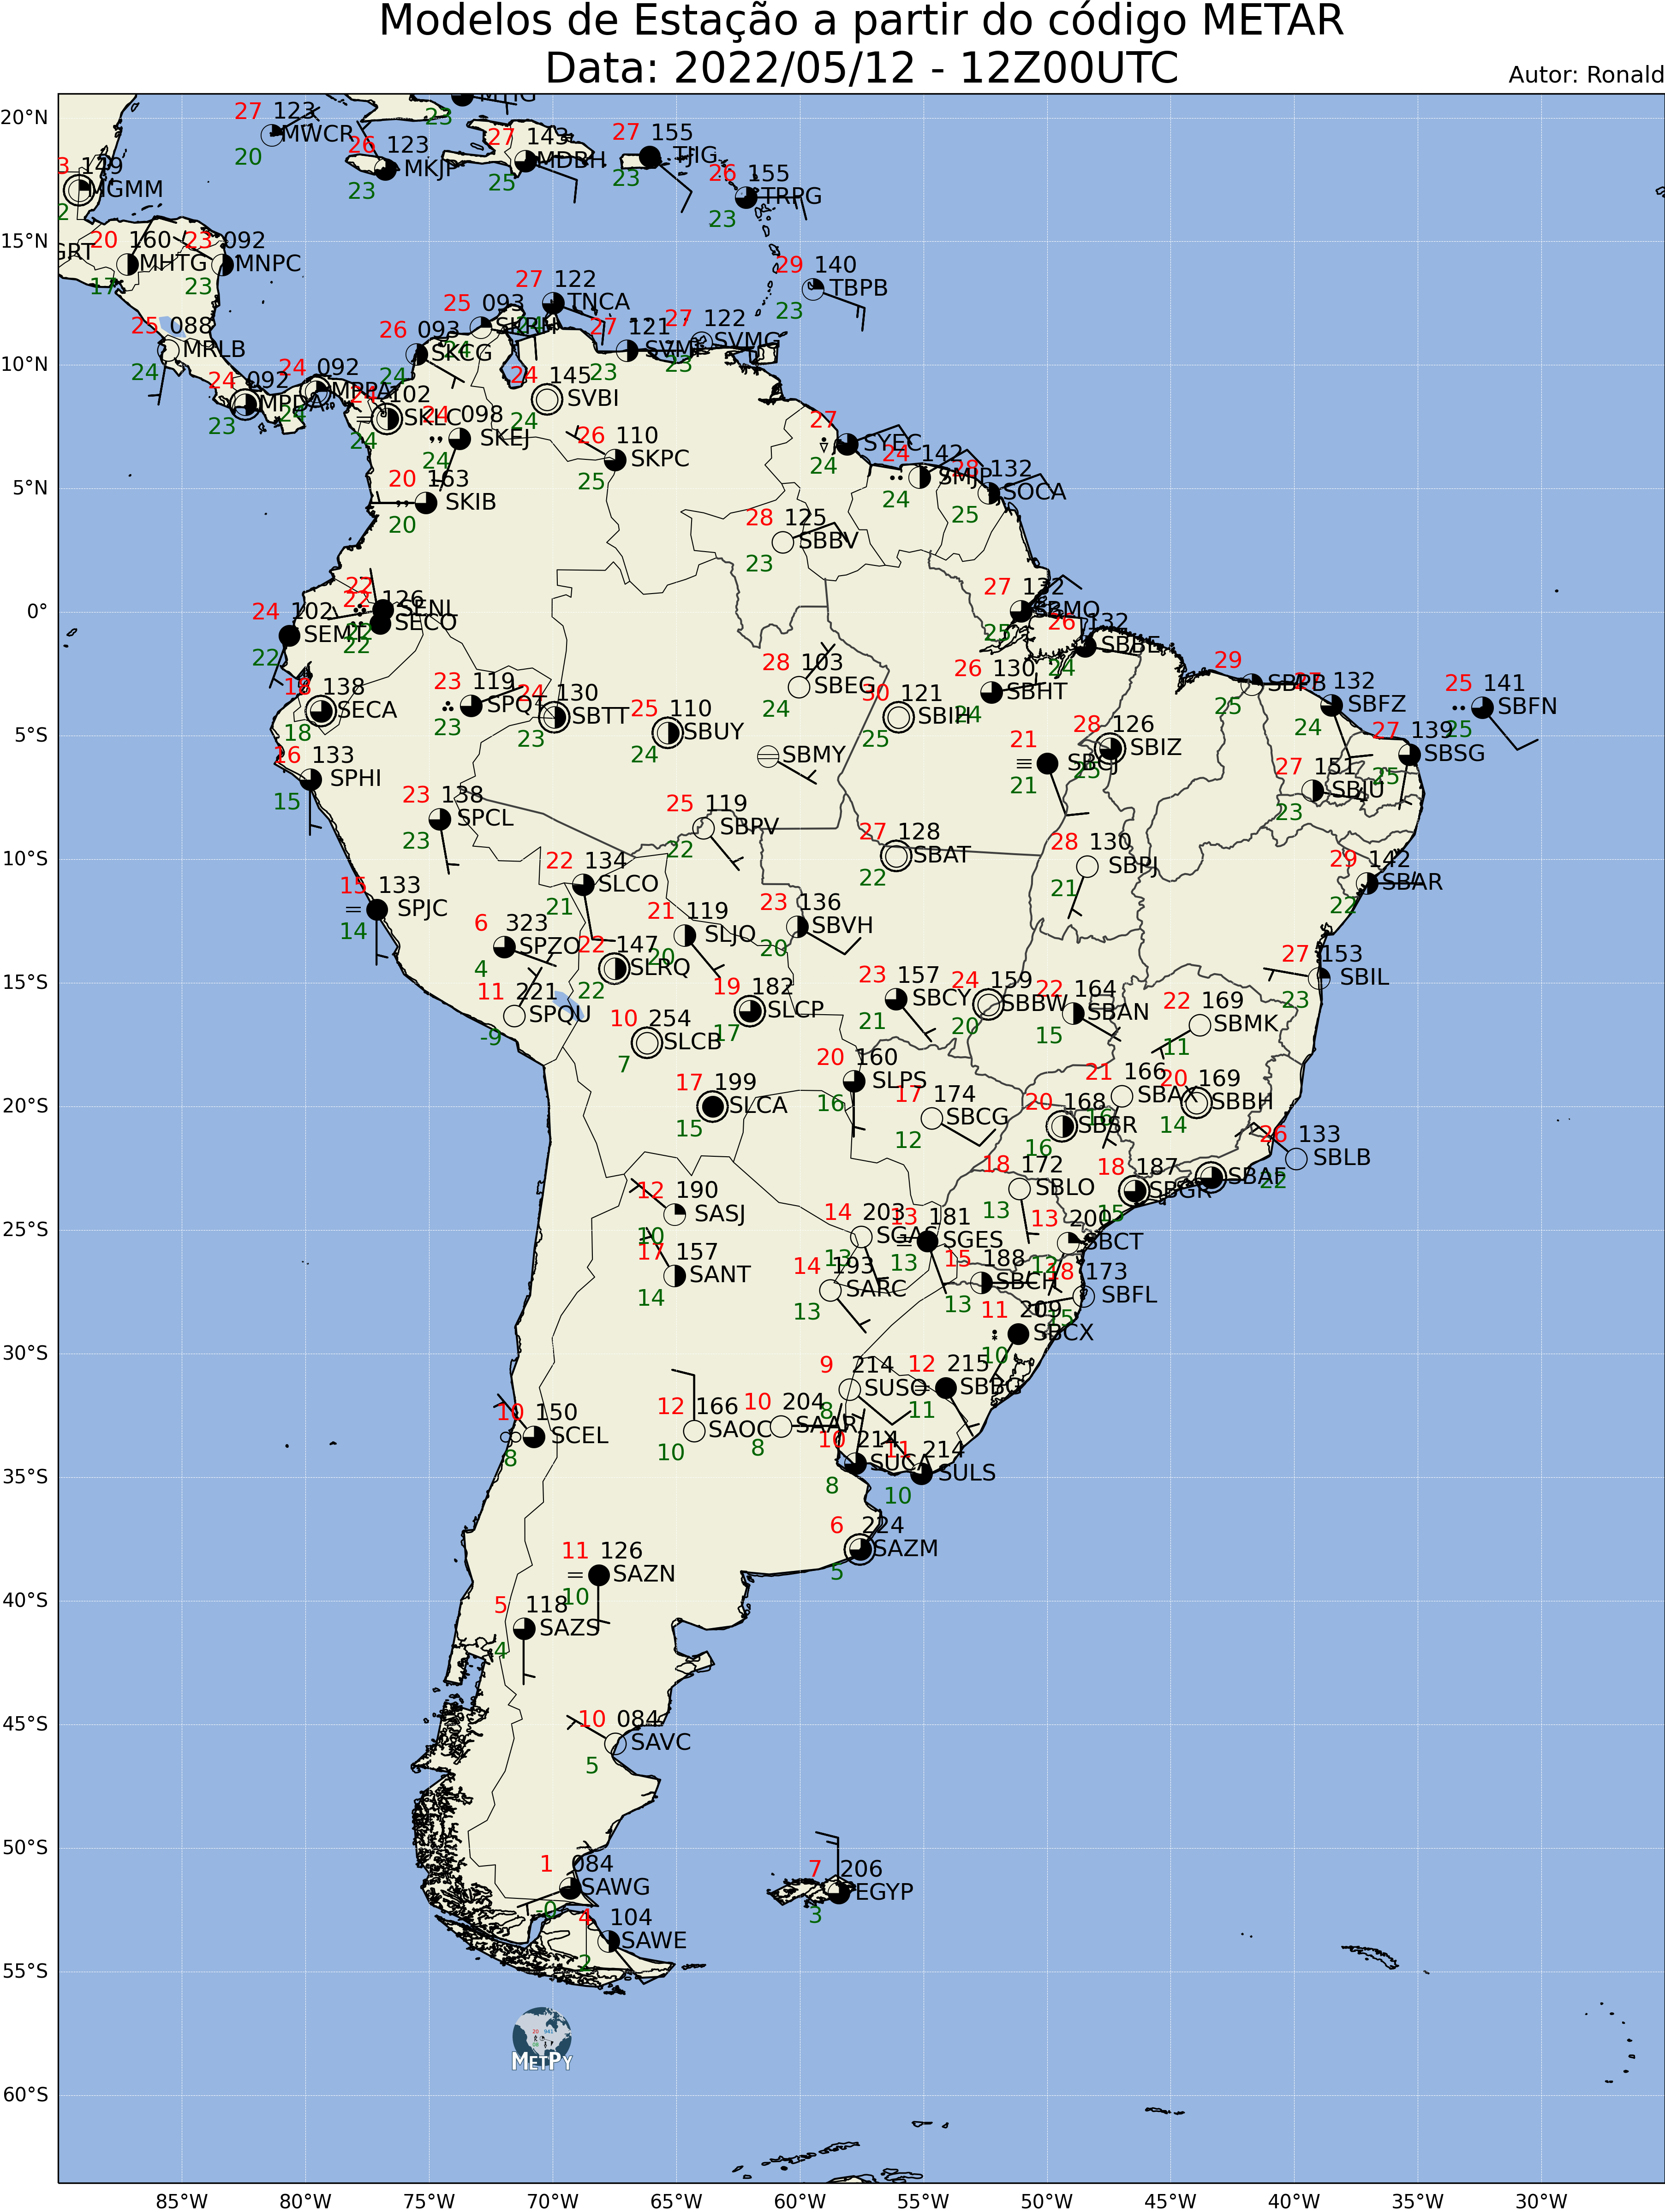

#**Instalando pacotes "Cartopy", "NetCDF4", "Metpy" , "Siphon"**

In [1]:
# Instalando o cartopy, com os pacotes e versões necessárias para o seu bom funcionamento no colab
!pip uninstall -y shapely
!pip install -q netcdf4
!pip install shapely cartopy --no-binary shapely --no-binary cartopy

Found existing installation: Shapely 1.8.2
Uninstalling Shapely-1.8.2:
  Successfully uninstalled Shapely-1.8.2
     |████████████████████████████████| 198 kB 14.3 MB/s 
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
    Preparing wheel metadata ... done
     |████████████████████████████████| 10.8 MB 76.9 MB/s 
  Installing build dependencies ... done
  Getting requirements to build wheel ... error
     |████████████████████████████████| 10.8 MB 28.6 MB/s 
  Installing build dependencies ... done
  Getting requirements to build wheel ... error
     |████████████████████████████████| 10.8 MB 27.8 MB/s 
  Installing build dependencies ... done
  Getting requirements to build wheel ... error
     |████████████████████████████████| 12.1 MB 45.3 MB/s 
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
    Preparing wheel metadata ... done
     |████████████████████████████████| 46 kB 4.1 MB/s 
  Created wheel for

O pacote **Metpy** é um pacote externo e portanto precisamos de instalar-lho.

**Nota:** A versão do Matplotlib 3.5.0 apresenta alguns conflitos com o **Metpy**. Para resolver esse problema, é necessário desinstalar o pacote **Matplotlib** (instalado por default) e instalar a **versão 3.3.0 do Matplotlib**.

In [2]:
!pip install siphon
!pip install matplotlib==3.3.0
!pip install metpy

     |████████████████████████████████| 69 kB 5.0 MB/s 
     |████████████████████████████████| 11.5 MB 13.7 MB/s 
  Attempting uninstall: matplotlib
    Found existing installation: matplotlib 3.2.2
    Uninstalling matplotlib-3.2.2:
      Successfully uninstalled matplotlib-3.2.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
albumentations 0.1.12 requires imgaug<0.2.7,>=0.2.5, but you have imgaug 0.2.9 which is incompatible.


     |████████████████████████████████| 367 kB 14.1 MB/s 
     |████████████████████████████████| 6.3 MB 49.6 MB/s 
     |████████████████████████████████| 209 kB 68.6 MB/s 


Para ter certeza de que foi instalado bem a versão **Matplotlib=3.3.0** vamos a fazer um **Restart runtime**. Para isso vamos a seguir os seguintes passos:

- Clic no menú **Runtime**
- Clic na opção **Restart runtime**

Com isso o código não deveria apresentar problemas na sua execução. 

Importando pacotes de processamento de dados (**Numpy e Pandas)**, pacotes para gerar nossas figuras (**Matplotlib e Cartopy**) e pacotes para plotar os modelos de estação (**Metpy**). Finalmente, também montamos nosso drive (**google.colab**) para acessar aos nossos códigos **METAR**. 


---



## **METAR (METeorological Aerodrome Report)**

Um código **METAR** é um mensagem codificado que indica as condições atmosféricas do aeródromo observadas em um momento específico. Os dados são obtidos da Estação Meteorológica Aeronaútica (**EMA**). 



As oficinas meteorológicas em um aeródromo são as seguintes:

**Oficina Meteorológica de Aeródromo (OMA)**

*   Funções: Previsão das condições meteorológicas de aeródromo (**TAF**)

**Oficina de Vigilância de Meteorologia (OVM)**

*   Funções: Elaboração de mensagens **SIGMET**, **AIRMET**

**Estação Meteorológica Aeronaútica (EMA)**

*   Funções: Observações meteorlógicas, elaboração de mensagens **METAR**

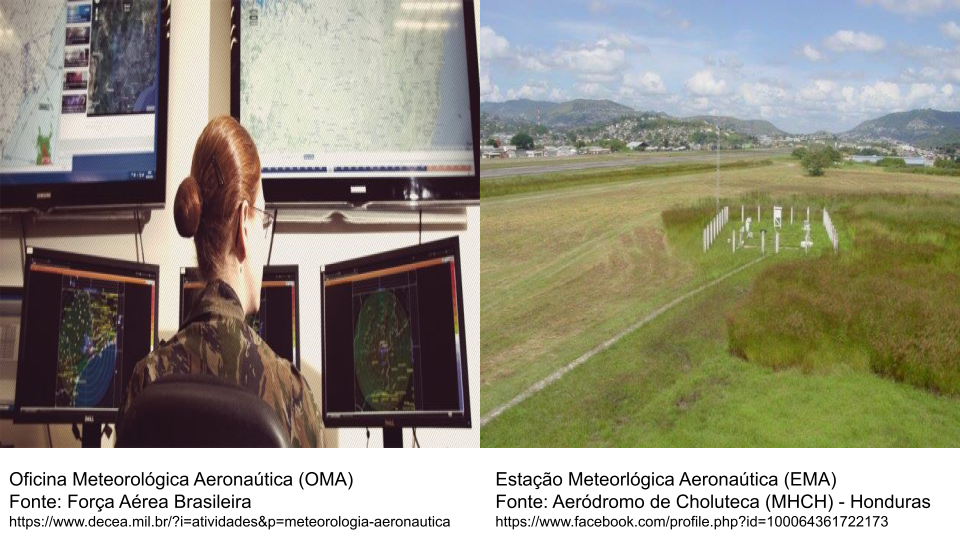

Outros códigos elaborado nas oficinas de Meteorologia Aeronaútica:

- SYNOP - AAXX
- SIGMET / AIRMET
- TEMP - TTAA, TTBB (Codificação dos dados de uma rariosondagem) 
- TAF - Previsão do tempo no aeródromo
- Aviso de cinza vulcanica.
- Aviso de cizalhadura do vento (windshear)
- AIREP (observação de aeronave)
- outros
 

**SPECI**

O código SPECI apresenta a mesma estrtura de um código **METAR**, com a diferença que o **SPECI** é emitido entre um METAR e outro, no caso se haver uma mudança abrupta nas condições atmosféricas do aeródromo (e.g. tempestade). 


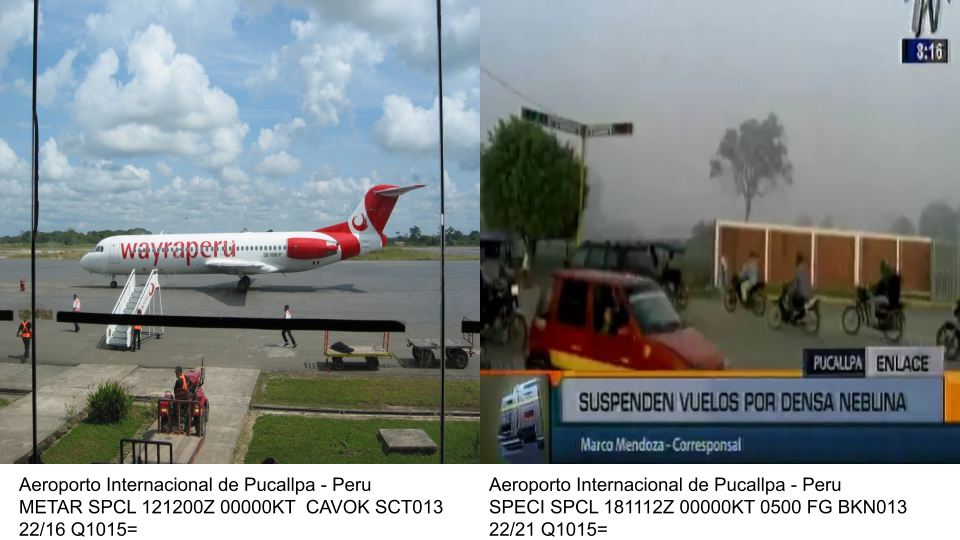

In [1]:
# Importando pacotes de processamento de dados
print('Ler pacotes de processamento de dados')
import numpy as np
import pandas as pd

# Importando pacotes para editar e gerar figuras
print('Ler pacotes para editar e gerar figuras')
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Importando pacote e funções para gerar os modelos de estação
print('Ler pacotes para gerar os modelos de estação')
from metpy.calc import reduce_point_density
from metpy.cbook import get_test_data
from metpy.io import metar
from metpy.plots import add_metpy_logo, current_weather, sky_cover, StationPlot

# Montando o drive
print('Montar o drive')
from google.colab import drive
drive.mount('/content/drive')

print('Terminou de ler pacotes e funções')

Ler pacotes de processamento de dados
Ler pacotes para editar e gerar figuras
Ler pacotes para gerar os modelos de estação
Montar o drive
Mounted at /content/drive
Terminou de ler pacotes e funções


Para acessar aos dados do METAR do globo enteiro que estão disponíveis, podemos acessar ao seguinte link e fazer o **download** num formato de arquivo **.txt**. O link é o seguinte:

- https://thredds-test.unidata.ucar.edu/thredds/catalog/noaaport/text/metar/catalog.html

Lendo o arquivo **.txt** com os dados do **METAR** disponíveis, utilizando a função **metar** do pacote **Metpy**.

Considerando que os nomes dos arquivos **.txt** com os códigos METAR apresentam a seguinte sintaxi:

**metar_YYYYMMDD_hhmm.txt**, onde:

- YYYY: ano
- MM: mês
- DD: dia
- hhmm: hora e minuto

**File:** metar_20220512_1200.txt

In [2]:
# Inserir o ano
ano = input("Escreves o ano: ")
print('                               ')
mes = input("Escrever o mês (e.g. 01, 02, ..., 09, 10, 12): ")
print('                               ')
dia = input("Escrever o dia: ")
print('                               ')
hora = input("Escrever a hora (e.g. 1200, 1500, 20000): ")
print('                               ')
pasta = input("Escrever o nome da sua pasta de trabalho: ")

Escreves o ano: 2022
                               
Escrever o mês (e.g. 01, 02, ..., 09, 10, 12): 05
                               
Escrever o dia: 20
                               
Escrever a hora (e.g. 1200, 1500, 20000): 1200
                               
Escrever o nome da sua pasta de trabalho: ronald


In [3]:
# Ler o arquivo .txt com os dados do METAR disponíveis
print('Ler dados do arquivo .txt')
data = metar.parse_metar_file('/content/drive/Shareddrives/ACA0522_2022/Scripts-Python/'+f'{pasta}/Aula_04/' + 'metar_' + f'{ano}{mes}{dia}_{hora}' + '.txt')

# Removendo filas sem valores de vento
print('Remover filas com dados faltantes do vento')
data = data.dropna(how='any', subset=['wind_direction', 'wind_speed'])

print(data)


Ler dados do arquivo .txt


Remover filas com dados faltantes do vento
           station_id   latitude   longitude  elevation           date_time  \
station_id                                                                    
K27K             K27K  38.233333  -84.433333      289.0 2022-05-20 11:55:00   
MMSL             MMSL  22.950000 -109.930000      140.0 2022-05-20 11:40:00   
MMAN             MMAN  25.870000 -100.230000      448.0 2022-05-20 11:40:00   
MMCS             MMCS  31.620000 -106.420000     1171.0 2022-05-20 11:40:00   
PAKU             PAKU  70.310000 -149.580000        2.0 2022-05-20 11:45:00   
...               ...        ...         ...        ...                 ...   
KQEX             KQEX  36.110000  128.370000       42.0 2022-05-20 12:30:00   
KQEX             KQEX  36.110000  128.370000       42.0 2022-05-20 12:40:00   
LIQC             LIQC  40.540000   14.200000      269.0 2022-05-20 12:55:00   
KLHW             KLHW  31.870000  -81.560000       14.0 2022-05-20 11:56:00   
SBCF     

Dividir os dados segundo o hemisfério. Criar dois DataFrame para armazenar dados segundo o hemisfério (**data_south**, **data_north**). Com o objetivo de facilitar o processo de graficar as barbelas de vento para cada hemisfério dos modelos de estação.

In [4]:
# DataFrame com dados do Hemisfério Sul
print('Dados para o Hemisfério Sul')
data_south = data[data.latitude < 0]

# Dataframe com dados do Hemisfério Norte
print('Dados para o Hemisfério Norte')
data_north = data[data.latitude > 0]

print(data_south)
data_north

Dados para o Hemisfério Sul
Dados para o Hemisfério Norte
           station_id  latitude  longitude  elevation           date_time  \
station_id                                                                  
FIMP             FIMP    -20.42      57.67       57.0 2022-05-20 12:00:00   
SESA             SESA     -2.20     -80.97        8.0 2022-05-20 12:00:00   
SECA             SECA     -4.00     -79.37     1221.0 2022-05-20 12:00:00   
SESM             SESM     -1.50     -78.05     1054.0 2022-05-20 12:00:00   
FQXA             FQXA    -25.05      33.61        5.0 2022-05-20 12:00:00   
...               ...       ...        ...        ...                 ...   
YSSY             YSSY    -33.95     151.16        3.0 2022-05-20 12:55:00   
NSTU             NSTU    -14.33    -170.72        3.0 2022-05-20 12:50:00   
EGYP             EGYP    -51.82     -58.45       74.0 2022-05-20 12:50:00   
SKLT             SKLT     -4.20     -69.93       84.0 2022-05-20 12:00:00   
SBCF             S

,station_id,latitude,longitude,elevation,date_time,wind_direction,wind_speed,wind_gust,visibility,current_wx1,...,air_temperature,dew_point_temperature,altimeter,current_wx1_symbol,current_wx2_symbol,current_wx3_symbol,remarks,air_pressure_at_sea_level,eastward_wind,northward_wind
station_id,,,,,,,,,,,,,,,,,,,,,
K27K,K27K,38.233333,-84.433333,289.0,2022-05-20 11:55:00,210.0,8.0,NaN,16093.440,NaN,...,22.0,17.0,29.77,0,0,0,AO1,1007.45,4.000000,6.928203
MMSL,MMSL,22.950000,-109.930000,140.0,2022-05-20 11:40:00,300.0,14.0,NaN,11265.408,NaN,...,14.0,12.0,29.84,0,0,0,RTS,1010.82,12.124356,-7.000000
MMAN,MMAN,25.870000,-100.230000,448.0,2022-05-20 11:40:00,0.0,0.0,NaN,8046.720,NaN,...,22.0,20.0,29.67,0,0,0,SLP/// 5//// 9// HZY ISOL SC RTS,1003.41,-0.000000,-0.000000
MMCS,MMCS,31.620000,-106.420000,1171.0,2022-05-20 11:40:00,250.0,14.0,NaN,16093.440,NaN,...,22.0,-4.0,29.79,0,0,0,SLP969 5//// 990 8/005 RTS,1003.76,13.155697,4.788282
PAKU,PAKU,70.310000,-149.580000,2.0,2022-05-20 11:45:00,260.0,13.0,NaN,16093.440,NaN,...,1.0,0.0,30.36,0,0,0,,1028.42,12.802501,2.257426
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
KQEX,KQEX,36.110000,128.370000,42.0,2022-05-20 12:20:00,300.0,3.0,NaN,9999.000,NaN,...,23.0,9.0,29.80,0,0,0,A02 TSNO,1009.30,2.598076,-1.500000
KQEX,KQEX,36.110000,128.370000,42.0,2022-05-20 12:30:00,300.0,3.0,NaN,9999.000,NaN,...,23.0,9.0,29.80,0,0,0,A02 TSNO,1009.30,2.598076,-1.500000
KQEX,KQEX,36.110000,128.370000,42.0,2022-05-20 12:40:00,280.0,3.0,NaN,9999.000,NaN,...,22.0,9.0,29.80,0,0,0,A02 TSNO,1009.32,2.954423,-0.520945


Fazendo uma projeção dos dados baseados nas coordenadas geográficas de cada DataFrame (Hemisfério Sul, Hemisfério Norte). Estabelecendo a densidade de estações que serão  inseridas na figura. O pacote **Cartopy** será utilizado. 

In [5]:
# Configurar projeção do Mapa
print('Configurar projeção do mapa - H. Sul')
proj = ccrs.PlateCarree()

# Utilizar o Cartopy para a projeção do mapa e localizar as estações no mapa,
# depois definir o número de estações inseridad configurando um rádio de 300 km.
print('Localizar estações e estabelcer número de estações - H. Sul')
point_locs = proj.transform_points(ccrs.PlateCarree(), data_south['longitude'].values,
                                   data_south['latitude'].values)
data_south = data_south[reduce_point_density(point_locs, 3)]

Configurar projeção do mapa - H. Sul
Localizar estações e estabelcer número de estações - H. Sul


Fazer o mesmo, só que agora com os dados do DataFrame do **Hermisfério Norte**

In [6]:
# Configurar projeção do Mapa
print('Configurar projeção do mapa - Dados do H. Norte')
proj = ccrs.PlateCarree()

# Utilizar o Cartopy para a projeção do mapa e localizar as estações no mapa,
# depois definir o número de estações inseridad configurando um rádio de 300 hm.
print('Localizar estações e estabelcer número de estações - H. Norte')
point_locs = proj.transform_points(ccrs.PlateCarree(), data_north['longitude'].values,
                                   data_north['latitude'].values)
data_north = data_north[reduce_point_density(point_locs, 3)]

Configurar projeção do mapa - Dados do H. Norte
Localizar estações e estabelcer número de estações - H. Norte


Inserir alguns dados como o nome da sua pasta, data do metar e seu nome:

In [7]:
# Inseir o nome da sua pasta
print('                              ')
Autor = input("Escrever seu nome:")
print('                              ')

                              
Escrever seu nome:Ronald
                              


Criando a figura com os modelos de estação a partir dos códigos **METAR**

Criando a figura
Estabelecer projeção e tamanho da figura
Adicionando elemntos à figura
HEMISFÉRIO SUL
HEMISFÉRIO NORTE


/usr/local/lib/python3.7/dist-packages/cartopy/io/__init__.py:241: DownloadWarning: Downloading: https://naciscdn.org/naturalearth/110m/physical/ne_110m_land.zip
  warnings.warn('Downloading: {}'.format(url), DownloadWarning)
/usr/local/lib/python3.7/dist-packages/cartopy/io/__init__.py:241: DownloadWarning: Downloading: https://naciscdn.org/naturalearth/110m/physical/ne_110m_ocean.zip
  warnings.warn('Downloading: {}'.format(url), DownloadWarning)
/usr/local/lib/python3.7/dist-packages/cartopy/io/__init__.py:241: DownloadWarning: Downloading: https://naciscdn.org/naturalearth/110m/physical/ne_110m_lakes.zip
  warnings.warn('Downloading: {}'.format(url), DownloadWarning)
/usr/local/lib/python3.7/dist-packages/cartopy/io/__init__.py:241: DownloadWarning: Downloading: https://naciscdn.org/naturalearth/110m/physical/ne_110m_coastline.zip
  warnings.warn('Downloading: {}'.format(url), DownloadWarning)
/usr/local/lib/python3.7/dist-packages/cartopy/io/__init__.py:241: DownloadWarning: Downl

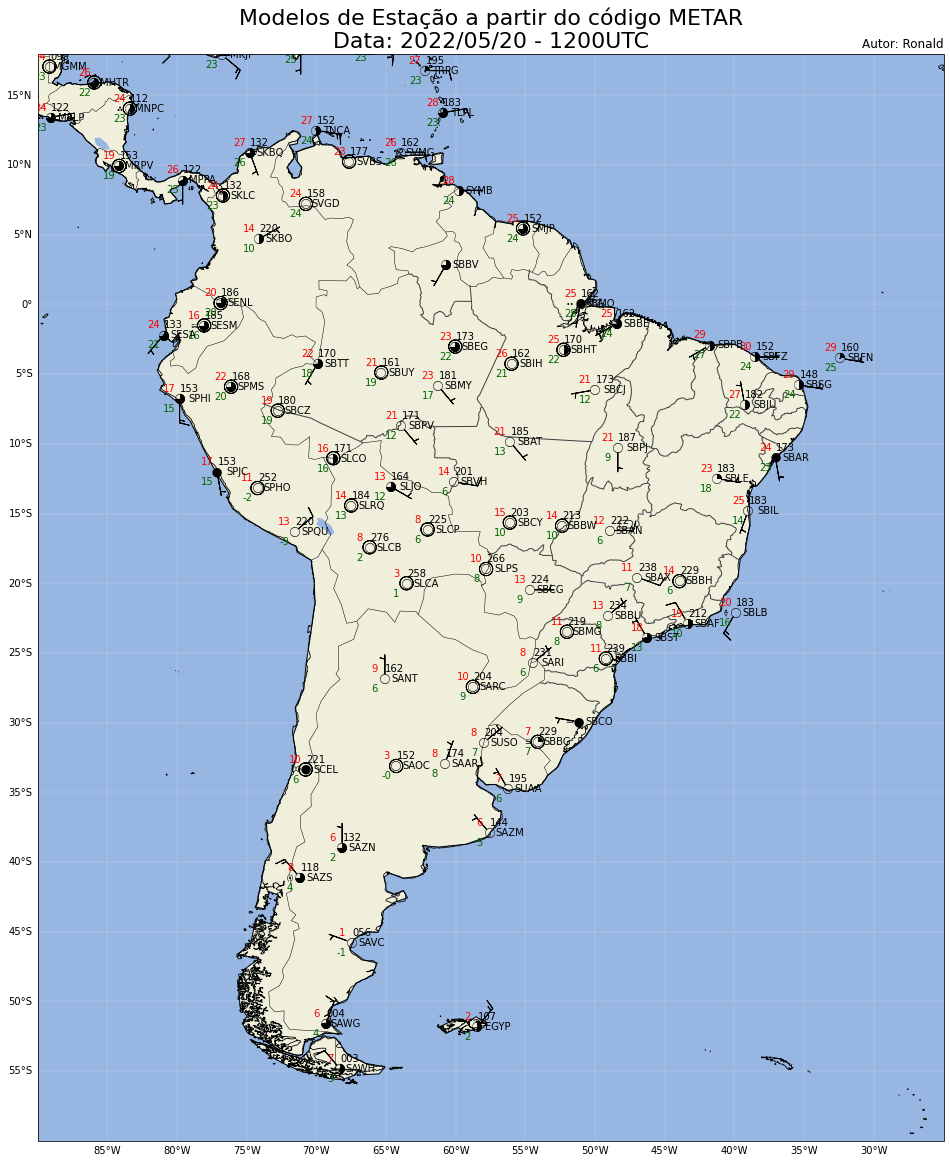

In [8]:
# Mudar o DPI da figura resultante, maiores valores do DPI melhoram a figura
print('Criando a figura')
plt.rcParams['savefig.dpi'] = 255

# Estabeler a projeção da figura criada
print('Estabelecer projeção e tamanho da figura')
fig = plt.figure(figsize=(20, 20))

ax = plt.axes(projection = ccrs.PlateCarree())

# Configurar os límites da Figura [Lon_min, LAt_min, Lon_max, Lat_max]
img_extent = [-90, -25, -60, 15]
ax.set_extent((-90, -25, -60, 18), ccrs.PlateCarree())

# Agregar elementos à figura
print('Adicionando elemntos à figura')
# Agregar continente
ax.add_feature(cfeature.LAND)
# Agregar o oceano
ax.add_feature(cfeature.OCEAN)
# Agregar lagoas
ax.add_feature(cfeature.LAKES)
# Agregar linha de costa
ax.add_feature(cfeature.COASTLINE)
# Agregando linhas de costa
ax.coastlines(resolution='10m', color='black', linewidth=0.8)
# Agregar estados
ax.add_feature(cfeature.STATES)
# Agregar linhas dividores entre paises
ax.add_feature(cfeature.BORDERS, edgecolor='black', linewidth=0.5)

# Agregando os estados do Brasil (mas também agrega os estados de The USA)
states_provinces = cfeature.NaturalEarthFeature(
    category='cultural',
    name='admin_1_states_provinces_lines',
    scale='50m',
    facecolor='none')
ax.add_feature(states_provinces, edgecolor='0.25')

# Agregando linhas de grade
gl = ax.gridlines(crs=ccrs.PlateCarree(), color='white', alpha=1.0, linestyle='--', linewidth=0.25, \
                  xlocs=np.arange(-180, 180, 5), ylocs=np.arange(-90, 90, 5), draw_labels=True)
gl.top_labels = False
gl.right_labels = False

# ----------------------------------------------------------------------------------------------------------

# HEMISFÉRIO SUL
print('HEMISFÉRIO SUL')
# Configurando o Plot para as estações do Hemisfério Sul

# Plot das estações especificando os eixos, assim como as latitudes/longitudes
# das estações (transformadas). Adicionar tamanho da fonte 8 pt.
stationplot = StationPlot(ax, data_south['longitude'].values, data_south['latitude'].values,
                          clip_on=True, transform=ccrs.PlateCarree(), fontsize=10)

# Agregar a temperuta do ar e temperatura do ponto de orvalho na parte superior e inferior
# do lado esquerdo do modelo de estação, respectivamente. 
# Temperatura do ar -> vermelho
# Temperatura de ponto de orvalho -> verde
stationplot.plot_parameter('NW', data_south['air_temperature'].values, color='red')
stationplot.plot_parameter('SW', data_south['dew_point_temperature'].values,
                           color='darkgreen')

# Agregar os valores de pressão ao nível do mar, utilizando os 3 digitos finais do
# valor estándar da pressão en décimas de milibares
stationplot.plot_parameter('NE', data_south['air_pressure_at_sea_level'].values,
                           formatter=lambda v: format(10 * v, '.0f')[-3:])

# Agregar os simbolos de cobertura de nuvens na ubicação central dos modelos de estação.
# Utiliza o mapeado "sky_cover" para converter os valores em códigos de fonte para os
# simbolos meteorológicos
stationplot.plot_symbol('C', data_south['cloud_coverage'].values, sky_cover)

# Agrega o estado atual do tempo à esquerda do centro. 
# Utiliza o mapeador "current_weather" para converter os símbolos à direita
stationplot.plot_symbol('W', data_south['current_wx1_symbol'].values, current_weather)

# Agregando as barbelas do vento para os METAR do H. Sul
stationplot.plot_barb(data_south['eastward_wind'].values, data_south['northward_wind'].values, flip_barb=True)

# Agrega o texto da identificação das estações. O lugar do texto está ubicado a 2 incrementos em X e 0 em Y
stationplot.plot_text((2, 0), data_south['station_id'].values)

# ----------------------------------------------------------------------------------------------------------------

# HEMISFÉRIO NORTE
print('HEMISFÉRIO NORTE')
# Configurando o plot para estações do Hemisfério Norte

# Plot das estações especificando os eixos, assi como as latitudes/longitudes
# das estações (transformadas). Adicionar tamanho da fonte 8 pt.
stationplot = StationPlot(ax, data_north['longitude'].values, data_north['latitude'].values,
                          clip_on=True, transform=ccrs.PlateCarree(), fontsize=10)

# Agregar a temperuta do ar e temperatura do ponto de orvalho na parte superior e inferior
# do lado esquerdo do modelo de estação, respectivamente. 
# Temperatura do ar -> vermelho
# Temperatura de ponto de orvalho -> verde
stationplot.plot_parameter('NW', data_north['air_temperature'].values, color='red')
stationplot.plot_parameter('SW', data_north['dew_point_temperature'].values,
                           color='darkgreen')

# Agregar os valores de pressão ao nível do mar, utilizando os 3 digitos finais do
# valor estándar da pressão en décimas de milibares
stationplot.plot_parameter('NE', data_north['air_pressure_at_sea_level'].values,
                           formatter=lambda v: format(10 * v, '.0f')[-3:])

# Agregar os simbolos de cobertura de nuvens na ubicação central dos modelos de estação.
# Utiliza o mapeado "sky_cover" para converter os valores em códigos de fonte para os
# simbolos meteorológicos
stationplot.plot_symbol('C', data_north['cloud_coverage'].values, sky_cover)

# Agrega o estado atual do tempo à esquerda do centro. 
# Utiliza o mapeador "current_weather" para converter os símbolos à direita
stationplot.plot_symbol('W', data_north['current_wx1_symbol'].values, current_weather)

# Agregando as barbelas do vento para os METAR do H. Sul
stationplot.plot_barb(data_north['eastward_wind'].values, data_north['northward_wind'].values)

# Agrega o texto da identificação das estações. O lugar do texto está ubicado a 2 incrementos em X e 0 em Y
stationplot.plot_text((2, 0), data_north['station_id'].values)

ax.set_title('Modelos de Estação a partir do código METAR\n' \
             + 'Data: 'f'{ano}/' + f'{mes}/' + f'{dia} - ' + f'{hora}UTC', size = 22)

ax.set_title('Autor: ' + f'{Autor}', loc='right')

plt.show()

# Salvando o plot
fig.savefig('/content/drive/Shareddrives/ACA0522_2022/Scripts-Python/'+\
            f'{pasta}' + '/Aula_04/' + 'METAR_' + f'{ano}_' + f'{mes}_' + f'{dia}_' + f'{hora}UTC'+ '.png',\
            format='png', bbox_inches='tight', pad_inches=0, dpi=300)